# Определение регионов по координатам — all_v2.csv

Датасет использует внутренние ID регионов (вероятно ЦИАН или аналог).
Задача: заменить их на официальные коды регионов РФ через spatial join по координатам.

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import time

pd.set_option('display.max_columns', None)

## 1. Загрузка данных

In [2]:
df = pd.read_csv('../data/raw/all_v2.csv')
print('Shape:', df.shape)
print('Уникальных значений region:', df['region'].nunique())
print('Диапазон region:', df['region'].min(), '—', df['region'].max())
print()
print('Топ-10 значений region:')
print(df['region'].value_counts().head(10).to_string())

Shape: (5477006, 13)
Уникальных значений region: 84
Диапазон region: 3 — 61888

Топ-10 значений region:
region
9654    1049435
2843     637224
81       500368
2661     461820
3        439511
6171     237289
2922     230545
3230     222652
5282     155645
3991     141633


In [3]:
# Загружаем границы регионов РФ
name_to_code = {
    'Republic of Adygea': 1, 'Republic of Bashkortostan': 2, 'Republic of Buryatia': 3,
    'Altai Republic': 4, 'Republic of Dagestan': 5, 'Republic of Ingushetia': 6,
    'Kabardino-Balkar Republic': 7, 'Republic of Kalmykia': 8, 'Karachay-Cherkess Republic': 9,
    'Republic of Karelia': 10, 'Komi Republic': 11, 'Mari El Republic': 12,
    'Republic of Mordovia': 13, 'Sakha (Yakutia) Republic': 14, 'Republic of North Ossetia-Alania': 15,
    'Republic of Tatarstan': 16, 'Tuva Republic': 17, 'Udmurt Republic': 18,
    'Republic of Khakassia': 19, 'Chechen Republic': 20, 'Chuvash Republic': 21,
    'Altai Krai': 22, 'Krasnodar Krai': 23, 'Krasnoyarsk Krai': 24,
    'Primorsky Krai': 25, 'Stavropol Krai': 26, 'Khabarovsk Krai': 27,
    'Amur Oblast': 28, 'Arkhangelsk Oblast': 29, 'Astrakhan Oblast': 30,
    'Belgorod Oblast': 31, 'Bryansk Oblast': 32, 'Vladimir Oblast': 33,
    'Volgograd Oblast': 34, 'Vologda Oblast': 35, 'Voronezh Oblast': 36,
    'Ivanovo Oblast': 37, 'Irkutsk Oblast': 38, 'Kaliningrad Oblast': 39,
    'Kaluga Oblast': 40, 'Kamchatka Krai': 41, 'Kemerovo Oblast': 42,
    'Kirov Oblast': 43, 'Kostroma Oblast': 44, 'Kurgan Oblast': 45,
    'Kursk Oblast': 46, 'Leningrad Oblast': 47, 'Lipetsk Oblast': 48,
    'Magadan Oblast': 49, 'Moscow Oblast': 50, 'Murmansk Oblast': 51,
    'Nizhny Novgorod Oblast': 52, 'Novgorod Oblast': 53, 'Novosibirsk Oblast': 54,
    'Omsk Oblast': 55, 'Orenburg Oblast': 56, 'Oryol Oblast': 57,
    'Penza Oblast': 58, 'Perm Krai': 59, 'Pskov Oblast': 60,
    'Rostov Oblast': 61, 'Ryazan Oblast': 62, 'Samara Oblast': 63,
    'Saratov Oblast': 64, 'Sakhalin Oblast': 65, 'Sverdlovsk Oblast': 66,
    'Smolensk Oblast': 67, 'Tambov Oblast': 68, 'Tver Oblast': 69,
    'Tomsk Oblast': 70, 'Tula Oblast': 71, 'Tyumen Oblast': 72,
    'Ulyanovsk Oblast': 73, 'Chelyabinsk Oblast': 74, 'Zabaykalsky Krai': 75,
    'Yaroslavl Oblast': 76, 'Moscow': 77, 'Saint Petersburg': 78,
    'Jewish Autonomous Oblast': 79, 'Nenets Autonomous Okrug': 83,
    'Khanty\u2013Mansi Autonomous Okrug \u2013 Yugra': 86,
    'Chukotka Autonomous Okrug': 87, 'Yamalo-Nenets Autonomous Okrug': 89,
}

regions = gpd.read_file('../data/russia_regions.geojson').to_crs('EPSG:4326')
regions['official_code'] = regions['name_latin'].map(name_to_code)
print('Регионов в GeoJSON:', len(regions))
print('Без кода:', regions['official_code'].isna().sum())

Регионов в GeoJSON: 83
Без кода: 0


## 2. Spatial Join на полном датасете (~5-10 минут)

In [4]:
mask_valid = (df['geo_lat'].between(41, 82)) & (df['geo_lon'].between(19, 192))
df_valid = df[mask_valid].copy().reset_index(drop=True)
df_invalid = df[~mask_valid].copy().reset_index(drop=True)

print(f'Валидных координат:   {len(df_valid):,}')
print(f'Невалидных координат: {len(df_invalid):,}')

t0 = time.time()
geometry_full = [Point(lon, lat) for lon, lat in zip(df_valid['geo_lon'], df_valid['geo_lat'])]
gdf_full = gpd.GeoDataFrame(df_valid, geometry=geometry_full, crs='EPSG:4326')

joined_full = gpd.sjoin(gdf_full, regions[['official_code', 'name_latin', 'geometry']], how='left', predicate='within')
joined_full = joined_full[~joined_full.index.duplicated(keep='first')]

print(f'Spatial join выполнен за {time.time()-t0:.0f} сек.')
print(f'Не попали в регион: {joined_full["official_code"].isna().sum():,}')

Валидных координат:   5,477,006
Невалидных координат: 0
Spatial join выполнен за 137 сек.
Не попали в регион: 9,357


## 3. Замена region на официальный код

In [5]:
# Добавляем официальный код, для невалидных координат оставляем NaN
df_valid['region_official'] = joined_full['official_code'].values

# Статистика
n_mapped = df_valid['region_official'].notna().sum()
n_unmapped = df_valid['region_official'].isna().sum()
print(f'Успешно определён регион: {n_mapped:,} ({n_mapped/len(df_valid)*100:.1f}%)')
print(f'Не удалось определить:    {n_unmapped:,} ({n_unmapped/len(df_valid)*100:.1f}%)')
print()

# Удаляем старый region, добавляем официальный
df_valid = df_valid.drop(columns=['region'])
df_valid = df_valid.rename(columns={'region_official': 'region'})

# Собираем обратно
df_result = pd.concat([df_valid, df_invalid], ignore_index=True)
print(f'Итоговый датасет: {len(df_result):,} строк')
df_result[['region', 'geo_lat', 'geo_lon']].head(10)

Успешно определён регион: 5,467,649 (99.8%)
Не удалось определить:    9,357 (0.2%)

Итоговый датасет: 5,477,006 строк


,region,geo_lat,geo_lon
0,78.0,59.805808,30.376141
1,50.0,55.683807,37.297405
2,52.0,56.295250,44.061637
3,23.0,44.996132,39.074783
4,50.0,55.918767,37.984642
5,50.0,55.908253,37.726448
6,77.0,55.621097,37.431002
7,78.0,59.875526,30.395457
8,63.0,53.195031,50.106952
9,50.0,55.736972,38.846457


## 4. Проверка: выборка точек с регионами

In [6]:
# Загружаем справочник для отображения названий
reg_ref = pd.read_csv('../data/russia_region_codes.csv', dtype={'kladr_id': str})
reg_ref['region_code'] = reg_ref['kladr_id'].str[:2].astype(int)
code_to_name = reg_ref.set_index('region_code')['geoname_name'].to_dict()

# Случайная выборка 20 строк
sample_check = df_result.dropna(subset=['region']).sample(20, random_state=42)[['region', 'geo_lat', 'geo_lon']].copy()
sample_check['region'] = sample_check['region'].astype(int)
sample_check['region_name'] = sample_check['region'].map(code_to_name)
sample_check = sample_check.reset_index(drop=True)
display(sample_check)

,region,geo_lat,geo_lon,region_name
0,54,54.946526,82.973030,Novosibirsk Oblast
1,54,55.056960,82.917552,Novosibirsk Oblast
2,54,55.060638,82.893707,Novosibirsk Oblast
3,54,55.012868,82.999999,Novosibirsk Oblast
4,58,53.224376,44.947116,Penza
5,54,55.030393,83.015545,Novosibirsk Oblast
6,50,55.559043,37.816396,Moscow Oblast
7,77,55.850078,37.406610,Moscow
8,63,53.125604,48.407549,Samara Oblast
9,23,44.630641,39.112225,Krasnodarskiy


## 5. Карта: распределение точек по регионам

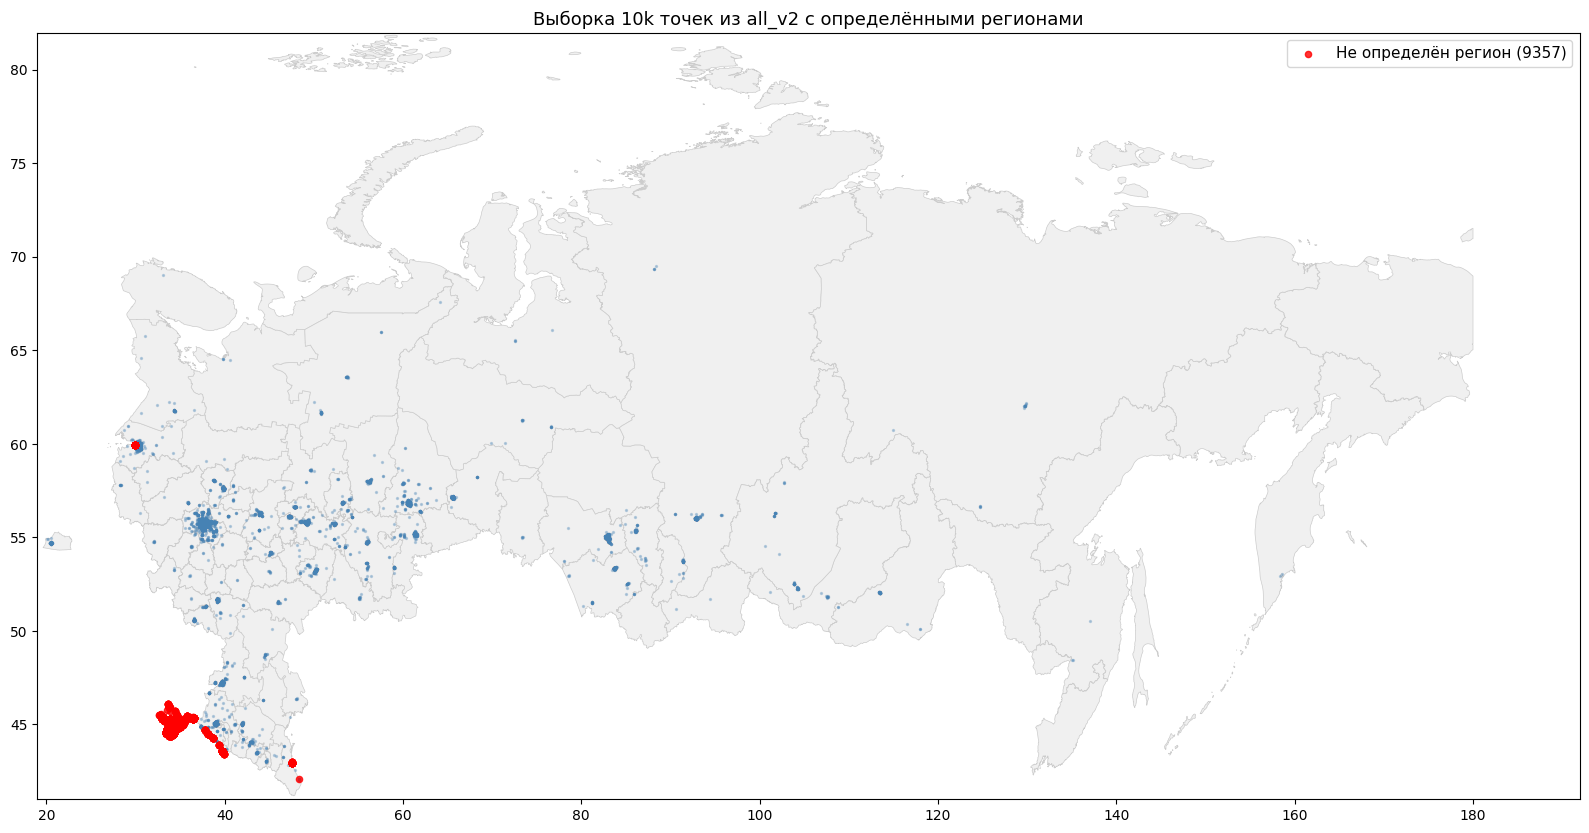

In [7]:
sample_map = df_result.dropna(subset=['region']).sample(10000, random_state=42)

fig, ax = plt.subplots(figsize=(16, 10))
regions.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)
ax.scatter(sample_map['geo_lon'], sample_map['geo_lat'], s=2, color='steelblue', alpha=0.3)

# Отмечаем точки без региона
no_region = df_result[df_result['region'].isna()]
if len(no_region) > 0:
    ax.scatter(no_region['geo_lon'], no_region['geo_lat'], s=20, color='red', alpha=0.8,
               zorder=5, label=f'Не определён регион ({len(no_region)})')
    ax.legend(fontsize=11)

ax.set_xlim(19, 192)
ax.set_ylim(41, 82)
ax.set_title('Выборка 10k точек из all_v2 с определёнными регионами', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Обработка точек без региона (Крым + море)

In [8]:
no_region = df_result[df_result['region'].isna()].copy()
print(f'Точек без региона: {len(no_region)}')
print(f'Координаты: lat {no_region["geo_lat"].min():.2f}–{no_region["geo_lat"].max():.2f}, '
      f'lon {no_region["geo_lon"].min():.2f}–{no_region["geo_lon"].max():.2f}')

mask_crimea_bbox = (
    no_region['geo_lat'].between(44.3, 46.0) &
    no_region['geo_lon'].between(32.5, 36.5)
)
mask_sevastopol = (
    no_region['geo_lat'].between(44.3, 44.75) &
    no_region['geo_lon'].between(33.3, 33.85)
)
n_crimea = mask_crimea_bbox.sum()
n_sevastopol = (mask_crimea_bbox & mask_sevastopol).sum()
n_sea = (~mask_crimea_bbox).sum()

print(f'\nКрым (код 91): {n_crimea - n_sevastopol}')
print(f'Севастополь (код 92): {n_sevastopol}')
print(f'В море (удалить): {n_sea}')

Точек без региона: 9357
Координаты: lat 42.11–59.95, lon 29.93–48.29

Крым (код 91): 4677
Севастополь (код 92): 2226
В море (удалить): 2454


In [9]:
mask_no_region = df_result['region'].isna()
mask_sev = mask_no_region & df_result['geo_lat'].between(44.3, 44.75) & df_result['geo_lon'].between(33.3, 33.85)
mask_crim = mask_no_region & df_result['geo_lat'].between(44.3, 46.0) & df_result['geo_lon'].between(32.5, 36.5) & ~mask_sev
mask_sea = mask_no_region & ~mask_crim & ~mask_sev

df_result.loc[mask_sev, 'region'] = 92
df_result.loc[mask_crim, 'region'] = 91

df_clean = df_result[~mask_sea].copy().reset_index(drop=True)

print(f'До: {len(df_result):,} строк')
print(f'Удалено (море): {mask_sea.sum():,}')
print(f'После: {len(df_clean):,} строк')
print(f'Осталось без региона: {df_clean["region"].isna().sum()}')

До: 5,477,006 строк
Удалено (море): 2,454
После: 5,474,552 строк
Осталось без региона: 0


In [10]:
output_path = '../data/processed/all_v2_region_fixed.csv'
df_clean.to_csv(output_path, index=False)
print(f'Сохранено: {output_path}')
print(f'Итог: {len(df_clean):,} строк, {df_clean.shape[1]} колонок')
print(f'Крым (91): {(df_clean["region"] == 91).sum():,}')
print(f'Севастополь (92): {(df_clean["region"] == 92).sum():,}')

Сохранено: ../data/processed/all_v2_region_fixed.csv
Итог: 5,474,552 строк, 13 колонок
Крым (91): 4,677
Севастополь (92): 2,226
